In [1]:
import os
import numpy as np
import hyperspy.api as hs

In [2]:
import colorcet as cc
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import seaborn as sns
from matplotlib.gridspec import GridSpec
import stem_analysis.plot as saplt

fluorescent_green = LinearSegmentedColormap.from_list(
    "black_fluorescent_green_white",
    ["black", "#39FF14", "white"],
)


from matplotlib.widgets import Button, Slider, RangeSlider

In [3]:
from tifffile import imread, imwrite

In [4]:
from skimage.filters import gaussian, window
from skimage.feature import peak_local_max, match_template
from scipy.ndimage import median_filter, rotate,shift
from skimage.transform import AffineTransform, warp


In [5]:
import atomap.api as am

/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


In [17]:
plt.style.use("/Users/nihy/Desktop/stem_analysis/src/stem_analysis/nature.mplstyle")

In [7]:
%matplotlib widget

# Load Data

In [8]:
work_dir = '/Users/nihy/Desktop/Working Data/EuAl4/Ptycho/Cryo Zone 100/ds8'

In [25]:
ptyrad_file = os.path.join(work_dir, "object_phase_cropped.tif")

In [10]:
#scan_file = '/Users/nihy/Desktop/Working Data/EuAl4/Ptycho/Cryo Zone 001/11/STEM SI.dm4'

In [11]:
#scan = hs.load(scan_file)[-1].data


In [12]:
#indr, indc = np.random.randint(0, 100, 2)
#dp_single = scan[indr-2:indr + 2, indc - 2 : indc + 2].mean((0,1))

In [13]:
#saplt.PlotDiff(dp_single, 0.297, cmap = fluorescent_green, norm = 'linear', vmin_percentile = 75, vmax_percentile = 100)
#plt.savefig(os.path.join(work_dir, "rand_dp_single.svg"), dpi=300, pad_inches = 0)

In [26]:
img_stack = imread(ptyrad_file)

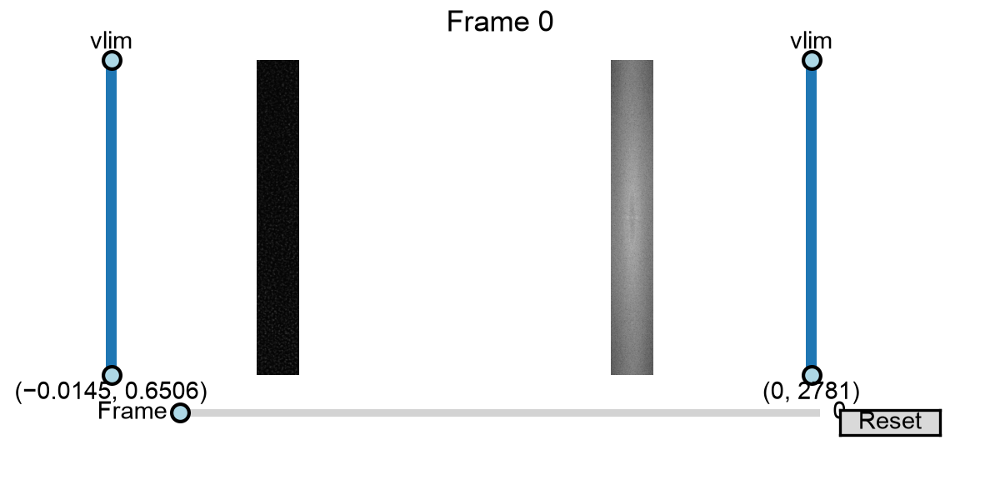

In [27]:
saplt.SliceViewer(img_stack)

In [28]:
dx, dy, dz = 0.02630, 0.02630, 1 # in nm

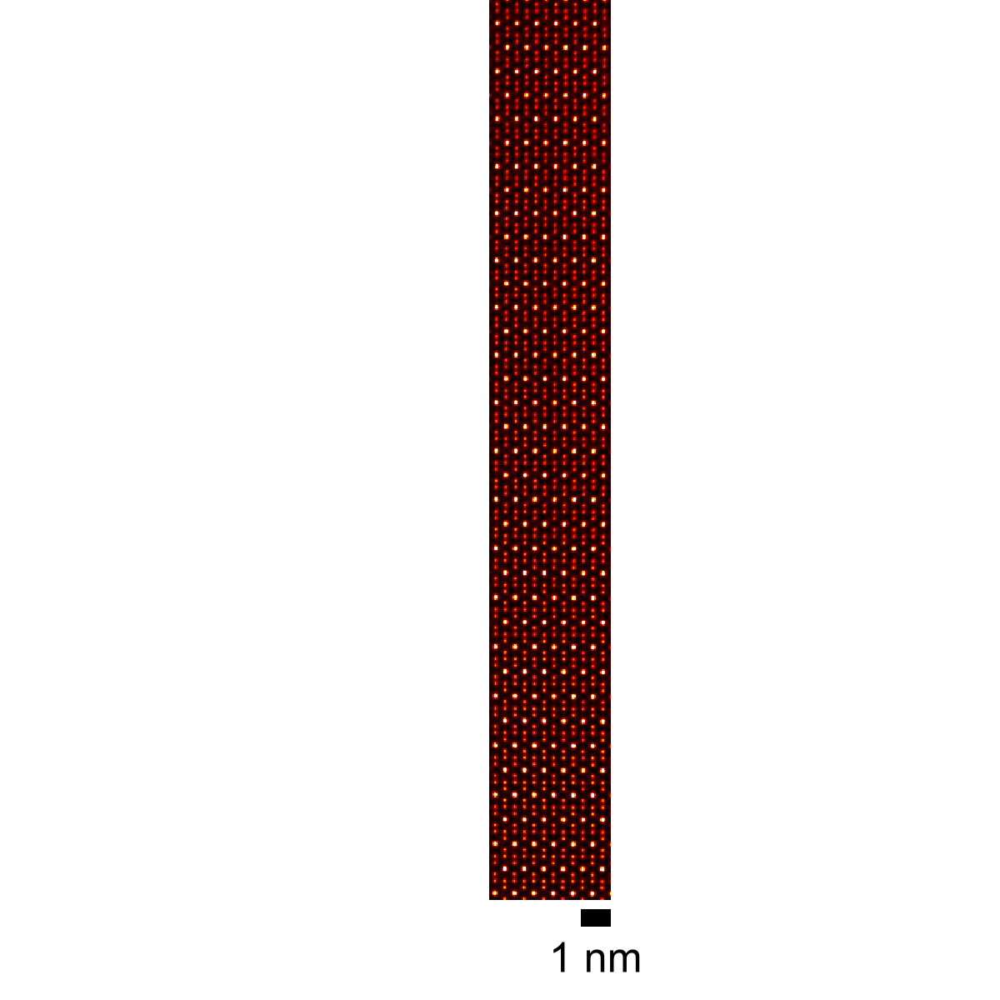

In [31]:
fig = plt.figure(figsize = (4,4))
saplt.PlotImage(fig,img_stack.sum(0), dx, cmap=cc.cm.fire, vmax = np.pi*4)
plt.savefig(
    os.path.join(work_dir, "ptyrad_sum_fire.svg"),
    dpi = 300,
    pad_inches = 0
)

# FFT

In [32]:
dq = 1/(img_stack.shape[1]*dx) # in 1/nm
dq

0.04996427554298677

In [33]:
w_2d = window('hann', img_stack.shape[1:])
w_3d = window('hann', img_stack.shape)

In [34]:
fft_slice_by_slice_abs = [np.abs(np.fft.fftshift(np.fft.fft2(img_stack[i]*w_2d))) for i in range(img_stack.shape[0])]

In [35]:
fft_3d_abs = np.abs(np.fft.fftshift(np.fft.fftn(img_stack*w_3d)))
fft_3d_abs.shape

(60, 761, 103)

In [50]:
pz, px, py = img_stack.shape
pz, px, py

(60, 761, 103)

(np.float64(-0.5), np.float64(102.5), np.float64(760.5), np.float64(-0.5))

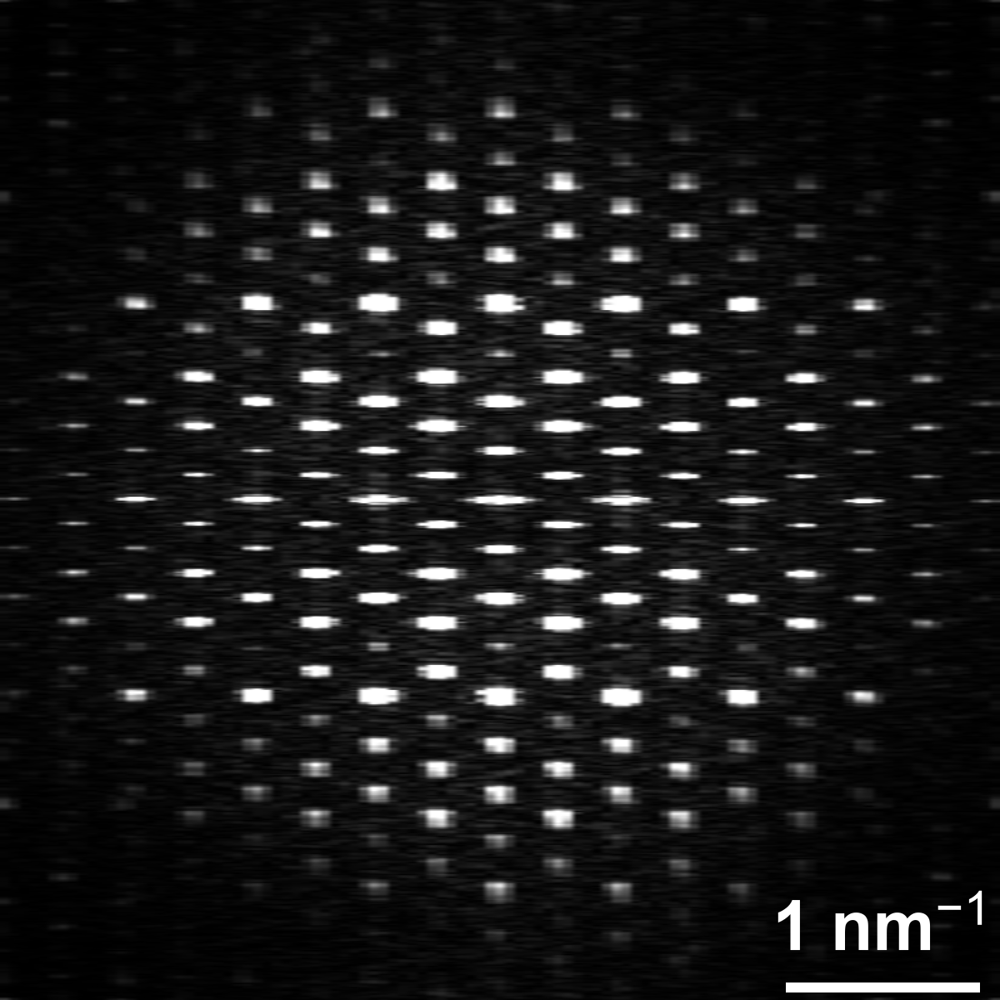

In [56]:
plt.figure(figsize = (4,4))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(fft_3d_abs[fft_3d_abs.shape[0]//2], cmap='gray', vmax = 0.2e3, aspect = py/px)
ax = plt.gca()
sbar = ScaleBar(
    dq,
    '1/nm',
    dimension = "si-length-reciprocal",
    location = 'lower right',
    length_fraction = 0.25,
    frameon = False,
    color = 'w',
    scale_loc = 'top',
    font_properties = {'size': 20, 'weight': 'bold'}
)
ax.add_artist(sbar)
ax.axis("off")
#plt.savefig(os.path.join(work_dir, "ptyrad_fft.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

# Find Lattice Points by a combined routine of template matching and lattice fitting

# Template matching

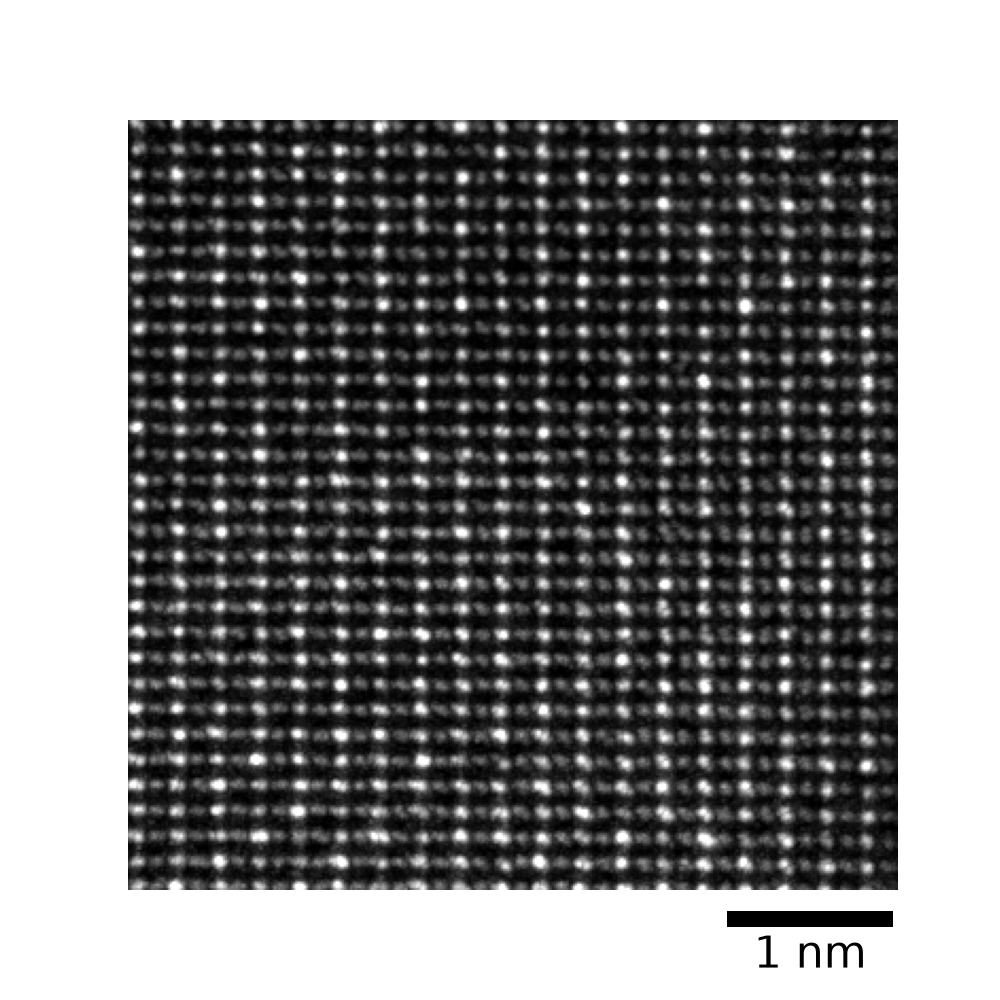

In [22]:
saplt.PlotImage(img_stack.max(0), dx, cmap='gray')

In [23]:
template = img_stack.sum(0)[51:51+25, 88:88+25]

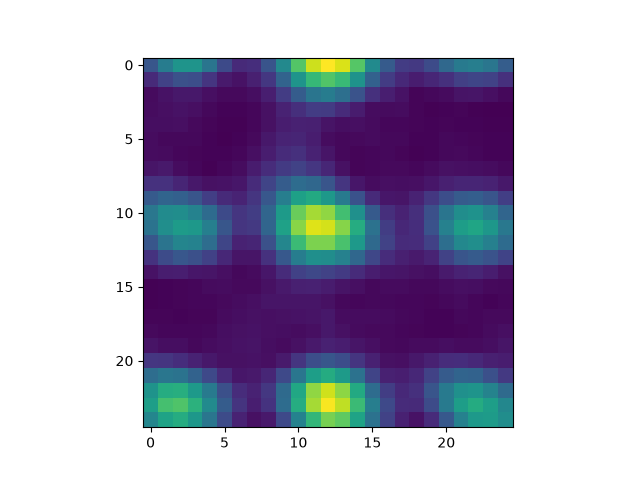

In [24]:
plt.figure()
plt.imshow(template)

In [25]:
matched = match_template(img_stack.sum(0), template, pad_input=True)

In [26]:
peaks = peak_local_max(matched, min_distance=7, threshold_abs=0.6)

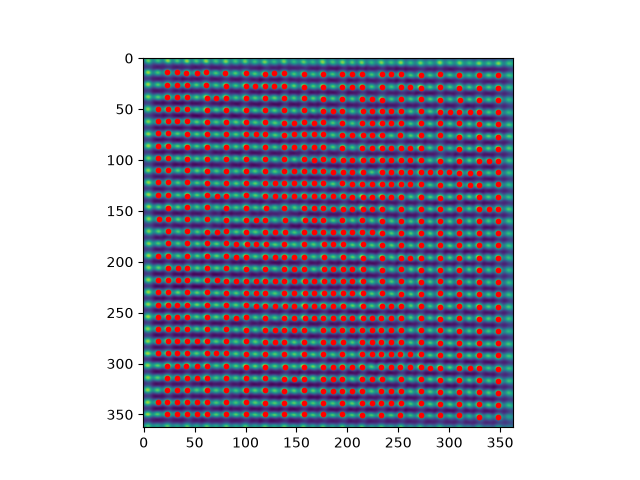

In [27]:
plt.figure()
plt.imshow(matched)
plt.scatter(peaks[:, 1], peaks[:, 0], color='r', s=10)

# Atomap Lattice Fitting

In [57]:
import hyperspy.api as hs

In [58]:
matched_hs = hs.signals.Signal2D(img_stack.sum(0))

In [59]:
s_peaks = am.get_feature_separation(matched_hs, separation_range=(2, 20), show_progressbar=False)
s_peaks.plot()

In [66]:
lattice_positions = am.get_atom_positions(matched_hs, separation=3, threshold_rel=0.1)

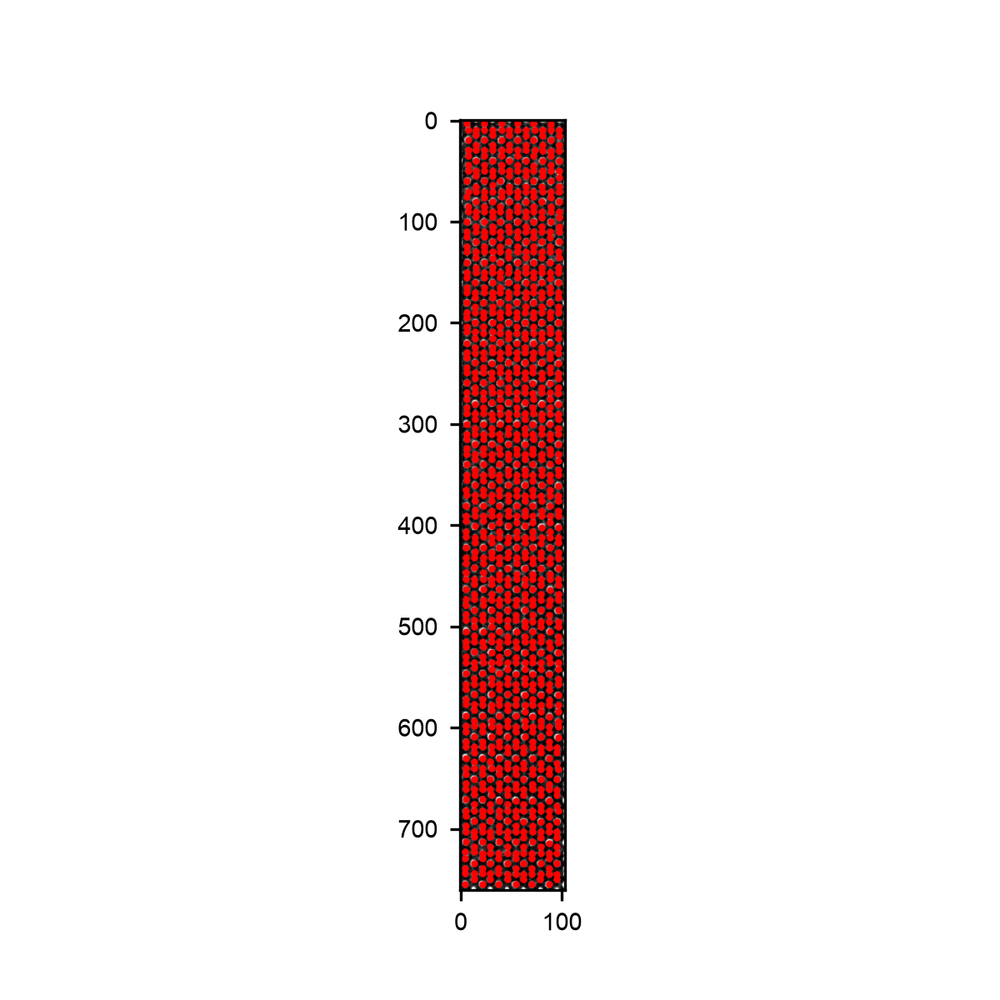

In [67]:
plt.figure(figsize = (4,4))
plt.imshow(img_stack.sum(0), cmap='gray', vmin = 0, vmax = 1*np.pi)
plt.scatter(lattice_positions[:, 0], lattice_positions[:, 1], color='r', s=1)

In [69]:
sublattice = am.Sublattice(lattice_positions, image = img_stack.sum(0))

Image data has negative values, with the lowest being -0.07313139736652374. This is not supported, and can lead to bad fitting results. To fix the negative values, by increasing all pixel values by -0.07313139736652374, use the fix_negative_values=True parameter


In [70]:
sublattice.find_nearest_neighbors()
sublattice.refine_atom_positions_using_center_of_mass()
sublattice.refine_atom_positions_using_2d_gaussian()

Gaussian fitting: 100%|██████████| 1110/1110 [00:03<00:00, 348.69it/s]


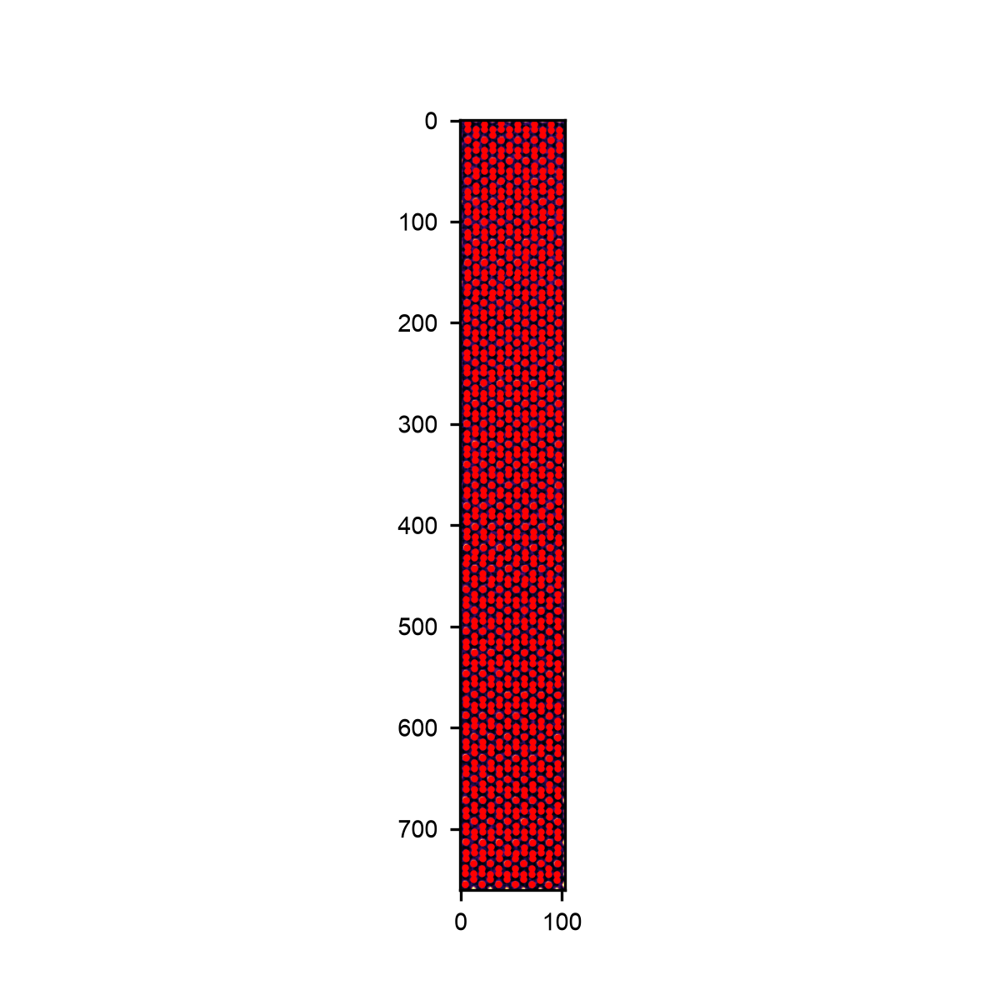

In [72]:
plt.figure(figsize = (4,4))
plt.imshow(img_stack.sum(0), cmap='inferno', vmax = 4, vmin = 0)
plt.scatter(sublattice.atom_positions[:, 0], sublattice.atom_positions[:, 1], color='r', s=1)


## Save Intermediate Result

In [73]:
sum_phase_lattice = am.Atom_Lattice(image=img_stack.sum(0), name='sum phase', sublattice_list=[sublattice])

Image data has negative values, with the lowest being -0.07313139736652374. This is not supported, and can lead to bad fitting results. To fix the negative values, by increasing all pixel values by -0.07313139736652374, use the fix_negative_values=True parameter


In [74]:
sum_phase_lattice.save(os.path.join(work_dir,"sum_phase_lattice.hdf5"), overwrite=True)

# Fit Layer-by-Layer anion positions
Using Anion because of less variations of intensities

In [75]:
slice_range = np.arange(0, pz)
slice_range.shape

(60,)

In [76]:
sublattice_layer_by_layer = []
for i in slice_range:
    s = am.Sublattice(sublattice.atom_positions, image = img_stack[i])
    s.find_nearest_neighbors()
    s.refine_atom_positions_using_center_of_mass()
    #s_anion.refine_atom_positions_using_2d_gaussian()
    sublattice_layer_by_layer.append(s)

Image data has negative values, with the lowest being -0.01203976571559906. This is not supported, and can lead to bad fitting results. To fix the negative values, by increasing all pixel values by -0.01203976571559906, use the fix_negative_values=True parameter
Center of mass: 100%|██████████| 1110/1110 [00:00<00:00, 53977.62it/s]
Image data has negative values, with the lowest being -0.014478994533419609. This is not supported, and can lead to bad fitting results. To fix the negative values, by increasing all pixel values by -0.014478994533419609, use the fix_negative_values=True parameter
Center of mass: 100%|██████████| 1110/1110 [00:00<00:00, 36199.96it/s]
Image data has negative values, with the lowest being -0.013683347031474113. This is not supported, and can lead to bad fitting results. To fix the negative values, by increasing all pixel values by -0.013683347031474113, use the fix_negative_values=True parameter
Center of mass: 100%|██████████| 1110/1110 [00:00<00:00, 41028.94

In [77]:
sublattice_layer_by_layer_pos = np.array([s.atom_positions for s in sublattice_layer_by_layer])
sublattice_layer_by_layer_pos.shape

(60, 1110, 2)

In [78]:
sublattice_layer_by_layer_pos_shift = sublattice_layer_by_layer_pos - np.mean(sublattice_layer_by_layer_pos, axis = 0, keepdims = True)

/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_22246/2324665161.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


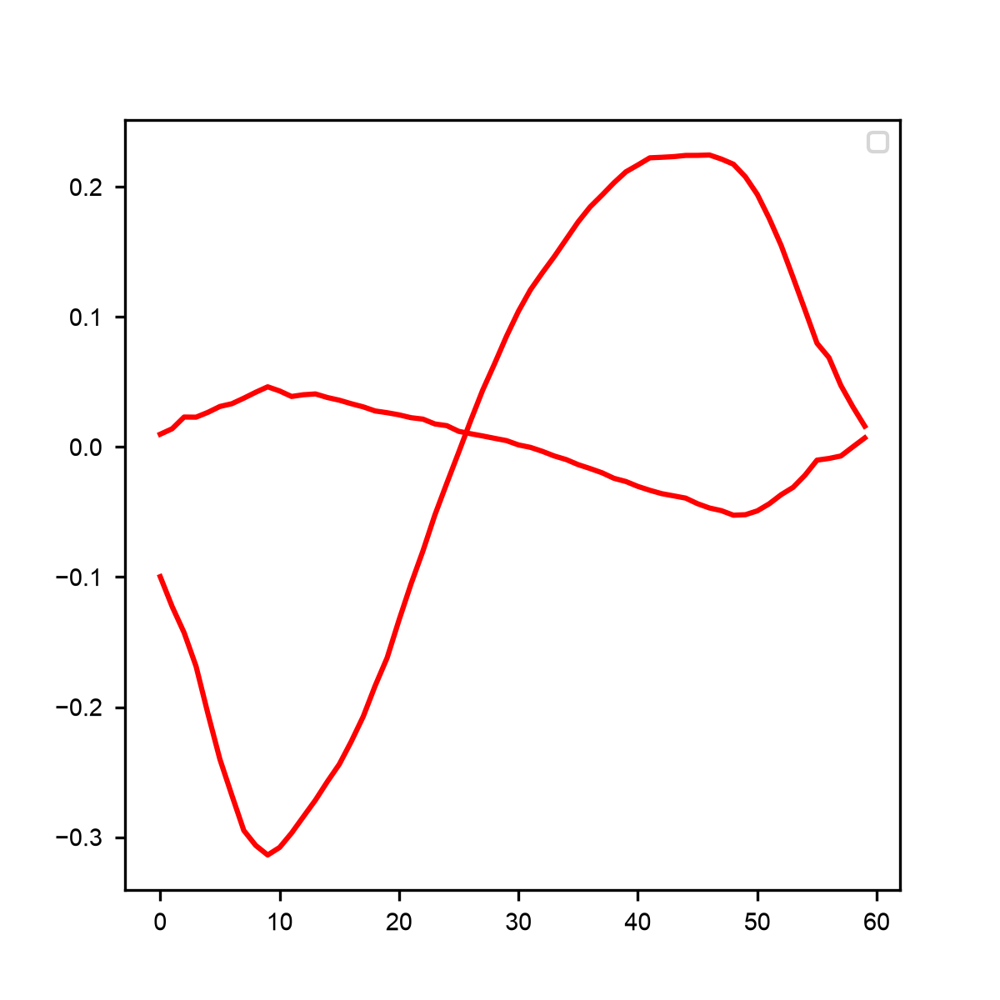

In [80]:
plt.figure(figsize = (4,4))
plt.plot(np.nanmedian(sublattice_layer_by_layer_pos_shift, axis=1), c ='r')
plt.legend()

In [ ]:
z_fit = np.arange(10,40)
cation_x = cation_positions[5:20,0]
cation_y = cation_positions[5:20,1]
coefficients_x = np.polyfit(z_fit, cation_x, 1)
coefficients_y = np.polyfit(z_fit, cation_y, 1)

In [50]:
px, py = np.poly1d(coefficients_x), np.poly1d(coefficients_y)

fitted_cation_x = px(np.arange(0,pz))
fitted_cation_y = py(np.arange(0,pz))
fitted_cation = np.column_stack((fitted_cation_x, fitted_cation_y))

In [51]:
# Shift image due to the mistilt

In [81]:
img_stack_shifted = np.zeros_like(img_stack)
for i in slice_range:
    img_stack_shifted[i] = shift(img_stack[i], shift = -np.nanmedian(sublattice_layer_by_layer_pos_shift, axis=1)[i][::-1], order = 1)
img_stack_shifted.min(), img_stack_shifted.max()    

(np.float32(-0.010562846), np.float32(0.63238245))

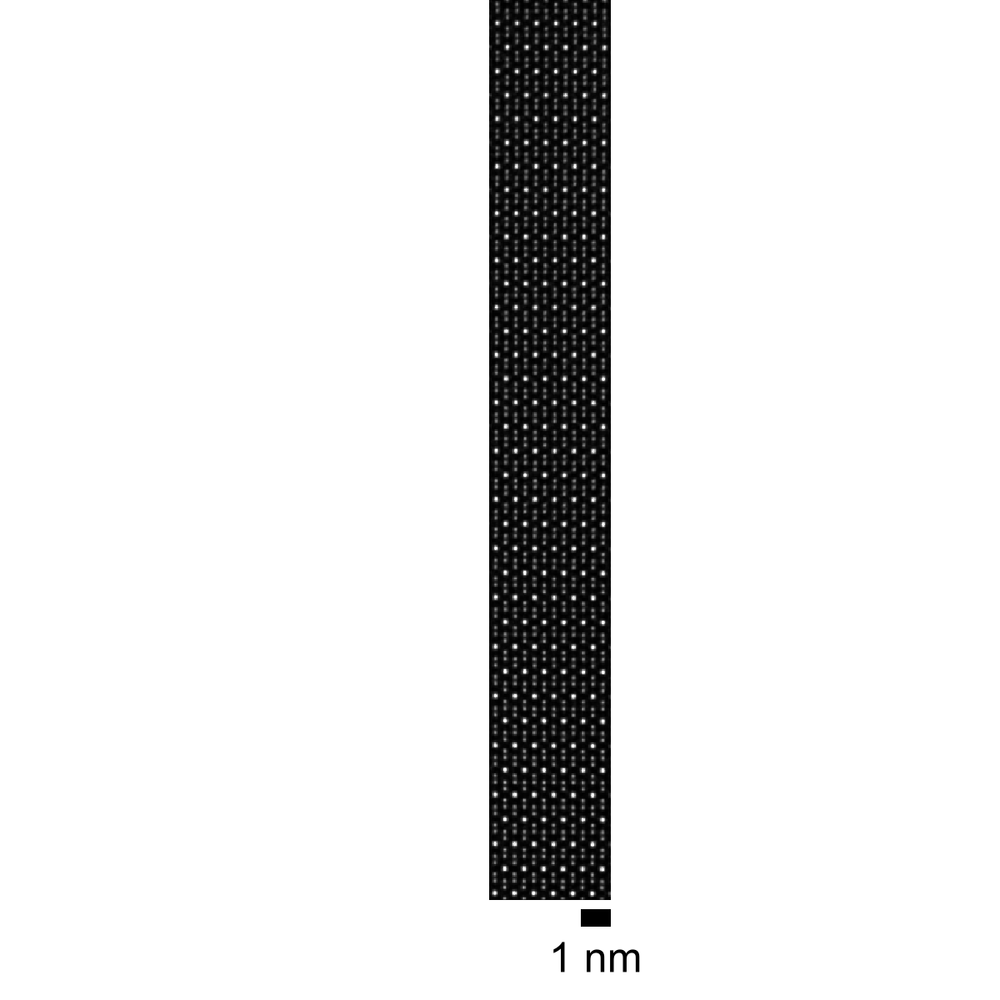

<Axes: >

In [86]:
fig = plt.figure(figsize = (4,4))
saplt.PlotImage(fig, img_stack_shifted.sum(axis=0), dx, vmax = 5*np.pi)


In [82]:
sum_phase_aligned = np.nansum(img_stack_shifted, axis=0)

In [84]:
fft_3d_abs = np.abs(np.fft.fftshift(np.fft.fftn(img_stack_shifted)))
fft_3d_abs.shape

(60, 761, 103)

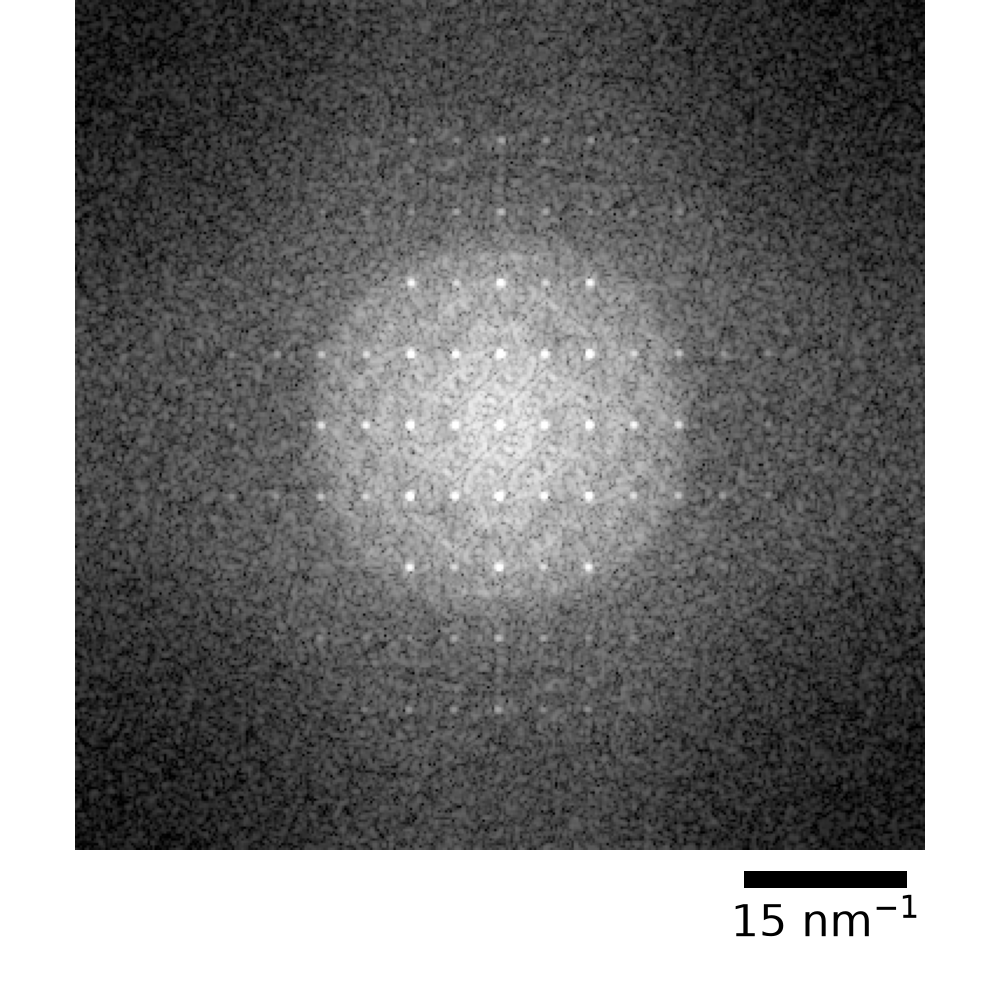

In [55]:
saplt.PlotDiff(fft_3d_abs[pz//2], dq, cmap = 'gray')
plt.savefig(os.path.join(work_dir, 'fft_3d_abs.svg'),
            dpi = 300,
            pad_inches = 0,
            transparent = True)

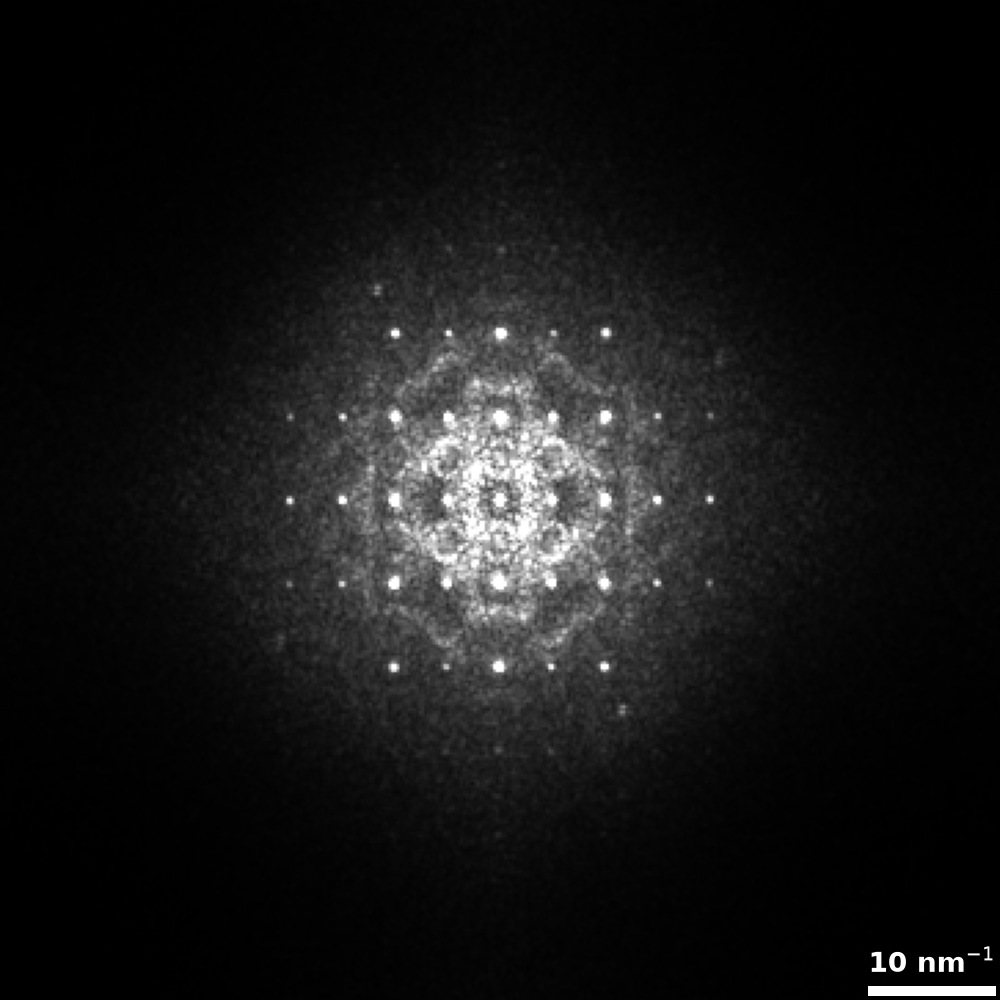

In [56]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(fft_3d_abs.sum(0), cmap='gray', vmax = 1000)
ax = plt.gca()
sbar = ScaleBar(
    dq,
    '1/nm',
    dimension = "si-length-reciprocal",
    location = 'lower right',
    fixed_value = 10,
    frameon = False,
    color = 'w',
    scale_loc = 'top',
    font_properties = {'size': 20, 'weight': 'bold'}
)
ax.add_artist(sbar)
ax.axis("off")
plt.savefig(os.path.join(work_dir, "ptyrad_fft_aligned.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

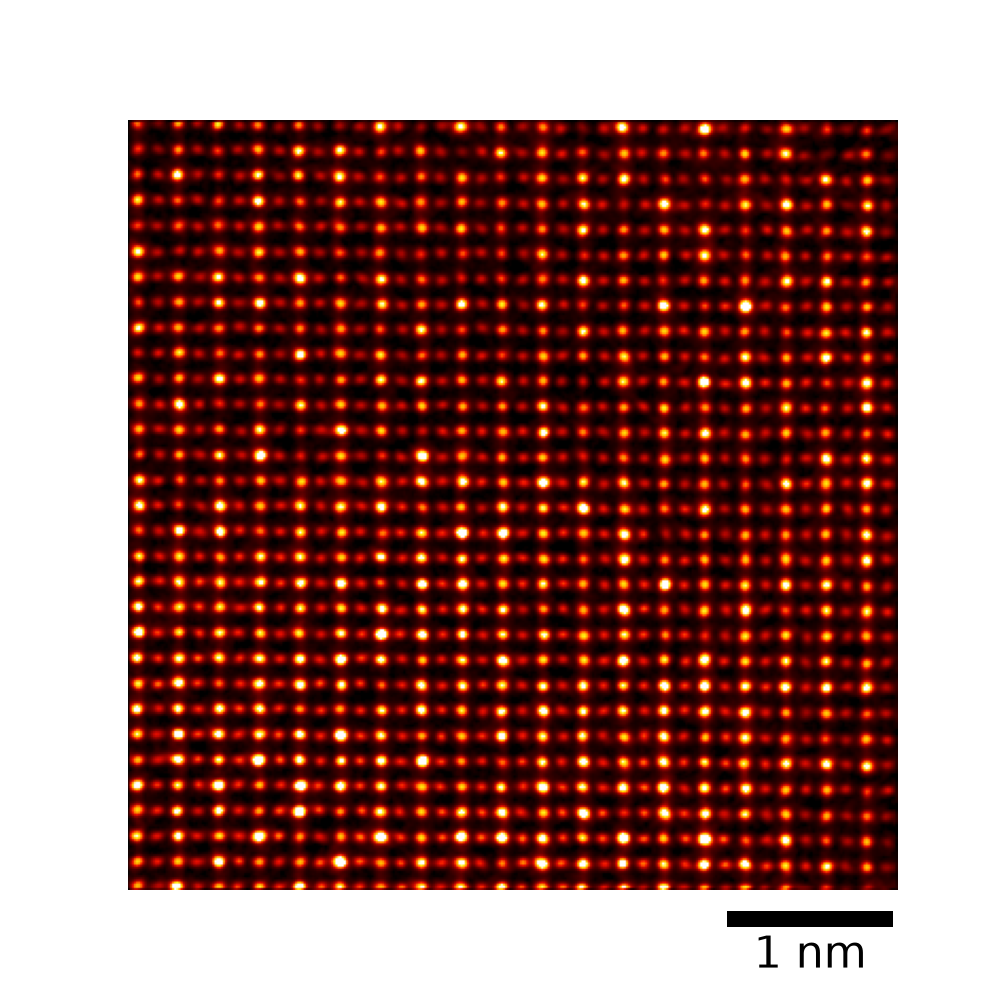

In [57]:
saplt.PlotImage(sum_phase_aligned, dx, cmap = cc.cm.fire)
plt.savefig(os.path.join(work_dir, "ptyrad_sum_aligned.svg"), 
            dpi = 300, 
            pad_inches = 0,
            transparent = True)

In [87]:
imwrite(os.path.join(work_dir,"object_phase_cropped_aligned_0_{}.tif".format(pz)), img_stack_shifted.astype(np.float32))

In [58]:
from matplotlib.animation import FuncAnimation, PillowWriter

fig_animation, ax_animation = plt.subplots(figsize=(6, 6))
im_animation = ax_animation.imshow(
    img_stack_shifted[0],
    cmap="inferno",
    vmin=0,
    vmax=np.percentile(img_stack_shifted, 99.5),
)
ax_animation.axis("off")
title_animation = ax_animation.set_title("Slice 0", color="white")

def update_animation(frame):
    im_animation.set_data(img_stack_shifted[frame])
    title_animation.set_text(f"Slice {frame}")
    return im_animation, title_animation

animation = FuncAnimation(
    fig_animation,
    update_animation,
    frames=img_stack_shifted.shape[0],
    interval=150,
    blit=True,
)

animation_path = os.path.join(work_dir, "object_phase_cropped_aligned_0_30.gif")
animation.save(
    animation_path,
    writer=PillowWriter(fps=7), 
    dpi = 300
)

plt.close(fig_animation)
print(f"Saved animation to: {animation_path}")

Saved animation to: /Users/nihy/Desktop/Working Data/EuAl4/Cryo Zone 001/11/1/object_phase_cropped_aligned_0_60.gif


In [89]:
cc.colorwheel[::256//4]

['#2e21ea', '#ef55f1', '#f0ed35', '#31ac28']